In [82]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

In [83]:
class PositionalEncoding(nn.Module):
  def __init__(self,d_model,dropout=0.1,max_len=5000):
    super().__init__()
    self.dropout=nn.Dropout(p=dropout)

    pe=torch.zeros(max_len,d_model)
    k=torch.arange(0,max_len)
    k.unsqueeze_(1)

    div_term=torch.exp(torch.arange(0,d_model,2)*-(math.log(10000.0)/d_model))
    pe[:,0::2]=torch.sin(k*div_term)
    pe[:,1::2]=torch.cos(k*div_term)

    pe.unsqueeze_(0)
    self.register_buffer('pe',pe) #saving in buffer as positional encoding need not to be changed

  def forward(self,x):
    x=x+self.pe[:,:x.size(1)].requires_grad_(False) #bcz we need positional encoding of size of a sentence
    return self.dropout(x)

In [84]:
class ScaledDotProductAttention(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self,Q,K,V,mask=None):
    d_k=Q.size(-1)
    scores=torch.matmul(Q,K.transpose(-2,-1))
    scores=scores/math.sqrt(d_k)

    if mask is not None:
      scores=scores.masked_fill(mask==0,-1e9)

    attention_weights=F.softmax(scores,dim=-1)
    output=torch.matmul(attention_weights,V)
    return output,attention_weights

In [85]:
class MultiHeadAttention(nn.Module):
  def __init__(self,d_model,num_heads):
    super().__init__()
    self.d_model=d_model
    self.num_heads=num_heads
    self.d_k=d_model//num_heads
    assert d_model%num_heads==0,"d_model must be divisible by num_heads"

    self.W_q=nn.Linear(d_model,d_model)
    self.W_k=nn.Linear(d_model,d_model)
    self.W_v=nn.Linear(d_model,d_model)

    self.attention=ScaledDotProductAttention()
    self.fc=nn.Linear(d_model,d_model)

  def forward(self,q,k,v,mask=None):
    Q=self.W_q(q)
    K=self.W_k(k)
    V=self.W_v(v)

    batch_size=q.size(0)
    Q=Q.view(batch_size,-1,self.num_heads,self.d_k).transpose(1,2)
    K=K.view(batch_size,-1,self.num_heads,self.d_k).transpose(1,2)
    V=V.view(batch_size,-1,self.num_heads,self.d_k).transpose(1,2)

    attention_output,attention_weights=self.attention(Q,K,V,mask)
    attention_output=attention_output.transpose(1,2).contiguous()
    attention_output=attention_output.view(batch_size,-1,self.d_model)
    output=self.fc(attention_output)

    return output,attention_weights

In [86]:
class FeedForward(nn.Module):
  def __init__(self,d_model,d_ff,dropout=0.1):
    super().__init__()
    self.linear1=nn.Linear(d_model,d_ff)
    self.relu=nn.ReLU()
    self.dropout=nn.Dropout(dropout)
    self.linear2=nn.Linear(d_ff,d_model)

  def forward(self,x):
    x=self.linear1(x)
    x=self.relu(x)
    x=self.dropout(x)
    x=self.linear2(x)
    return x

In [87]:
class EncoderLayer(nn.Module):
  def __init__(self,d_model,num_heads,d_ff,dropout=0.1):
    super().__init__()
    self.attention=MultiHeadAttention(d_model,num_heads)
    self.feed_forward=FeedForward(d_model,d_ff,dropout)
    self.norm1=nn.LayerNorm(d_model)
    self.norm2=nn.LayerNorm(d_model)
    self.dropout1=nn.Dropout(dropout)
    self.dropout2=nn.Dropout(dropout)

  def forward(self,x,mask):
    attention_output,attention_weights=self.attention(x,x,x,mask)
    x=self.norm1(x+self.dropout1(attention_output))
    feed_forward_output=self.feed_forward(x)
    x=self.norm2(x+self.dropout2(feed_forward_output))
    return x,attention_weights

In [88]:
class DecoderLayer(nn.Module):
  def __init__(self,d_model,num_heads,dff,dropout=0.1):
    super().__init__()
    self.self_attention=MultiHeadAttention(d_model,num_heads)
    self.cross_attention=MultiHeadAttention(d_model,num_heads)
    self.feed_forward=FeedForward(d_model,dff,dropout)

    self.norm1=nn.LayerNorm(d_model)
    self.norm2=nn.LayerNorm(d_model)
    self.norm3=nn.LayerNorm(d_model)

    self.dropout1=nn.Dropout(dropout)
    self.dropout2=nn.Dropout(dropout)
    self.dropout3=nn.Dropout(dropout)

  def forward(self,x,encoder_ouput,src_mask=None,tgt_mask=None):
    #masked self attention layer
    attention_output,_=self.self_attention(x,x,x,tgt_mask)
    x=self.norm1(x+self.dropout1(attention_output))

    #cross attention layer
    attention_output,attention_weights=self.cross_attention(x,encoder_ouput,encoder_ouput,src_mask)
    x=self.norm2(x+self.dropout2(attention_output))

    #feed forward network
    feed_forward_output=self.feed_forward(x)
    x=self.norm3(x+self.dropout3(feed_forward_output))

    return x,attention_weights

In [89]:
class Encoder(nn.Module):
  def __init__(self,vocab_size,d_model,num_heads,dff,num_layers,dropout=0.1,max_len=5000):
    super().__init__()
    self.embedding=nn.Embedding(vocab_size,d_model)
    self.pos_encoding=PositionalEncoding(d_model,dropout,max_len)
    self.dropout=nn.Dropout(dropout)
    self.layers=nn.ModuleList(
        [EncoderLayer(d_model,num_heads,dff,dropout)
        for _ in range(num_layers)]
    )

  def forward(self,x,mask=None):
    x=self.embedding(x)
    x=self.pos_encoding(x)
    x=self.dropout(x)
    for layer in self.layers:
      x,_=layer(x,mask)

    return x

In [90]:
class Decoder(nn.Module):
  def __init__(self,vocab_size,d_model,num_heads,dff,num_layers,dropout=0.1,max_len=5000):
    super().__init__()
    self.embedding=nn.Embedding(vocab_size,d_model)
    self.pos_encoding=PositionalEncoding(d_model,dropout,max_len)
    self.dropout=nn.Dropout(dropout)
    self.layers=nn.ModuleList(
        [DecoderLayer(d_model,num_heads,dff,dropout)
        for _ in range(num_layers)]
    )

  def forward(self,x,encoder_output,src_mask=None,tgt_mask=None):
    x=self.embedding(x)
    x=self.pos_encoding(x)
    x=self.dropout(x)

    attention=None
    for layer in self.layers:
      x,attention=layer(x,encoder_output,src_mask,tgt_mask)

    return x

In [91]:
class Transformer(nn.Module):
  def __init__(self,src_vocab_size,tgt_vocab_size,d_model,num_heads,dff,num_layers,dropout=0.1,max_len=5000):
    super().__init__()
    self.encoder=Encoder(src_vocab_size,d_model,num_heads,dff,num_layers,dropout,max_len)
    self.decoder=Decoder(tgt_vocab_size,d_model,num_heads,dff,num_layers,dropout,max_len)
    self.fc=nn.Linear(d_model,tgt_vocab_size)

  def forward(self,src,tgt,src_mask=None,tgt_mask=None):
    encoder_output=self.encoder(src,src_mask)
    decoder_output=self.decoder(tgt,encoder_output,src_mask,tgt_mask)
    final_output=self.fc(decoder_output)

    return final_output

Dataset preprocessing

In [92]:
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter
from torch.utils.data import Dataset,DataLoader

In [93]:
df=pd.read_csv('Dataset_English_Hindi.csv')
df=df.sample(8000,random_state=42)
df.dropna(inplace=True)
df["Hindi"]="<start> "+df["Hindi"]+" <end>"
df.head()

,English,Hindi
116099,Above them is the Court of the Subordinate Civ...,"<start> इनके ऊपर अधीनस्थ सिविल न्यायाधीश , प्र..."
118915,"Again , being a sovereign ruler of his country...",<start> अपने देश में सर्वसत्ता सम्पन्न सम्राट ...
45690,There is a ton of information on that fire hyd...,<start> उस आग बुझाने वाले यत्र के पास बहुत सी ...
109776,as a vending device during the floods in easte...,<start> या फ़िर फेरी लगाने के लिये इस्तेमाल कर...
3995,Nationalist-Secessionist,<start> राष्ट्रवादी-अलगाववादी <end>


In [94]:
train_df,test_df=train_test_split(df,test_size=0.2,random_state=42)

In [95]:
counter=Counter()
for sentence in train_df["English"]:
  counter.update(sentence.lower().split())
source_vocab={"<pad>":0,"<unk>":1}
for word,_ in counter.most_common():
  source_vocab[word]=len(source_vocab)

counter=Counter()
for sentence in train_df["Hindi"]:
  counter.update(sentence.lower().split())
target_vocab={"<pad>":0,"<unk>":1}
for word,_ in counter.most_common():
  target_vocab[word]=len(target_vocab)

idx2word={v:k for k,v in target_vocab.items()}

In [96]:
def numericalize(sentence,vocab):
  tokens=sentence.lower().split()
  ids=[]
  for token in tokens:
    ids.append(vocab.get(token,vocab["<unk>"]))
  return ids

MAX_LEN=50
def padding(seq,max_len):
  seq=seq[:max_len]
  while len(seq)<max_len:
    seq.append(0)
  return seq

In [97]:
class TranslationDataset(Dataset):
  def __init__(self,data):
    self.english=data["English"].tolist()
    self.hindi=data["Hindi"].tolist()

  def __len__(self):
    return len(self.english)

  def __getitem__(self,idx):
    src=numericalize(self.english[idx],source_vocab)
    trg=numericalize(self.hindi[idx],target_vocab)

    src=padding(src,MAX_LEN)
    trg=padding(trg,MAX_LEN)

    return (torch.tensor(src),torch.tensor(trg))

In [98]:
train_dataset=TranslationDataset(train_df)
test_dataset=TranslationDataset(test_df)
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [99]:
model=Transformer(
    src_vocab_size=len(source_vocab),
    tgt_vocab_size=len(target_vocab),
    d_model=512,
    num_heads=8,
    dff=2048,
    num_layers=6,
    dropout=0.1,
    max_len=MAX_LEN
)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
criterion=nn.CrossEntropyLoss(ignore_index=0)

optimizer=torch.optim.Adam(model.parameters(),lr=0.0001)

In [100]:
epochs=15
losses=[]
for epoch in range(epochs):
  model.train()
  epoch_loss=0

  for src,tgt in train_loader:
    src=src.to(device)
    tgt=tgt.to(device)

    optimizer.zero_grad()
    output=model(src,tgt[:,:-1])
    loss=criterion(output.reshape(-1,output.shape[-1]),tgt[:,1:].reshape(-1))
    loss.backward()
    optimizer.step()
    epoch_loss+=loss.item()
  epoch_loss/=len(train_loader)
  losses.append(epoch_loss)
  print(f"Epoch: {epoch+1}, Loss: {epoch_loss}")

Epoch: 1, Loss: 7.383251886367798
Epoch: 2, Loss: 6.150530154705048
Epoch: 3, Loss: 5.24522221326828
Epoch: 4, Loss: 4.423947536945343
Epoch: 5, Loss: 3.7620436120033265
Epoch: 6, Loss: 3.224374096393585
Epoch: 7, Loss: 2.766068937778473
Epoch: 8, Loss: 2.3637279838323595
Epoch: 9, Loss: 2.027282775044441
Epoch: 10, Loss: 1.726668537259102
Epoch: 11, Loss: 1.4643431448936461
Epoch: 12, Loss: 1.244272270798683
Epoch: 13, Loss: 1.0527770918607713
Epoch: 14, Loss: 0.8740906783938408
Epoch: 15, Loss: 0.72379584223032


In [101]:
#for testing
model.eval()
def translate(sentence,max_len=50):
  src=numericalize(sentence,source_vocab)
  src=padding(src,MAX_LEN)
  src=torch.tensor(src).unsqueeze(0).to(device)
  encoder_input=src
  tgt=[target_vocab["<start>"]]
  for _ in range(max_len):
    decoder_input=torch.tensor(tgt).unsqueeze(0).to(device)
    with torch.no_grad():
      output=model(encoder_input,decoder_input)
    next_token=output.argmax(-1)[0,-1].item()
    tgt.append(next_token)
    if next_token==target_vocab["<end>"]:
      break

  words=[]
  for idx in tgt:
    word=idx2word[idx]
    if word in ["<start>","<pad>"]:
      continue
    if word=="<end>":
      break
    words.append(word)

  return " ".join(words)

In [102]:
test_df = test_df.reset_index(drop=True)

from nltk.translate.bleu_score import corpus_bleu,SmoothingFunction

references=[]
hypotheses=[]

for _,row, in test_df.iterrows():
  english=row["English"]
  actual=row["Hindi"]

  predicted=translate(english)
  actual=actual.replace("<start>","")
  actual=actual.replace("<end>","")
  references.append([actual.split()])
  hypotheses.append(predicted.split())

smooth=SmoothingFunction().method1
bleu_score=corpus_bleu(references,hypotheses,smoothing_function=smooth)
print(f"BLEU Score: {bleu_score*100}")

BLEU Score: 0.0008737302854526073


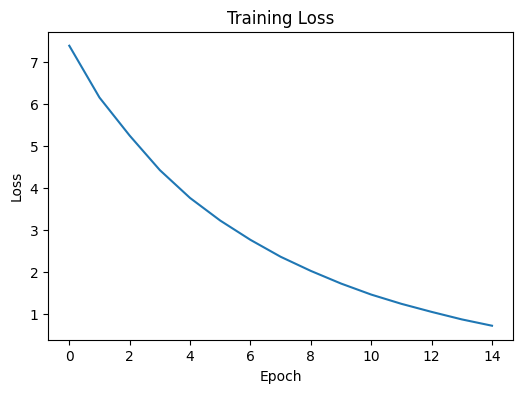

In [103]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()